In [ ]:
## Import Libraries

In [48]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [50]:
df = pd.read_csv('/kaggle/input/datasets/tahmidakter/clean-products/cleaned_products_20260831_163948.csv')
print(df.shape)
df.head()

(620, 569)


,product_id,asin,title,full_title,url,image_url,price,current_price,original_price,discount,rating,detailed_rating,reviews_count,detailed_reviews_count,brand,manufacturer,availability,description,features,dimensions,best_sellers_rank,date_first_available,is_prime,is_sponsored,video_url,video_thumbnail,keyword,scraped_at,created_at,updated_at,technical_details,reviews,reviews_count_actual,tech_brand_name,tech_hand_orientation,tech_upc,tech_set_name,tech_number_of_items,tech_included_components,tech_instrument,tech_item_weight,tech_model_name,tech_model_number,tech_manufacturer_part_number,tech_warranty_description,tech_color,tech_top_material_type,tech_body_material_type,tech_back_material_type,tech_neck_material_type,tech_fretboard_material_type,tech_string_material_type,tech_material_type,tech_guitar_bridge_system,tech_number_of_strings,tech_scale_length,tech_item_dimensions_l_x_w_x_h,tech_item_dimensions,tech_instrument_size,tech_item_type_name,tech_compatible_devices,tech_output_wattage,tech_number_of_bands,tech_speaker_size,tech_power_source,tech_output_channel_quantity,tech_amplifier_type,tech_connector_type,tech_enclosure_material,tech_item_dimensions_d_x_w_x_h,tech_unit_count,tech_mfr_part_number,tech_sound_profile,tech_number_of_packs,tech_guitar_pickup_configuration,tech_string_nut_width,tech_global_trade_identification_number,tech_coating_description,tech_string_gauge,tech_recommended_uses_for_product,tech_surface_recommendation,tech_maximum_weight_recommendation,tech_mounting_type,tech_maximum_weight_capacity,tech_additional_features,tech_number_of_hooks,tech_product_style,tech_shape,tech_finish_types,tech_model_series,tech_operation_mode,tech_closure_type,tech_capacity,tech_strap_type,tech_pocket_description,tech_handle_type,tech_number_of_compartments,tech_water_resistance_level,tech_style_name,tech_pattern,tech_size,tech_manufacturer_warranty_description,tech_compatible_phone_models,tech_special_features,tech_input_voltage,tech_amperage,tech_total_usb_ports,tech_wattage,tech_output_current,tech_output_voltage,tech_current_rating,tech_main_power_connector_type,tech_number_of_power_levels,tech_total_usb_20_ports,tech_power_plug,tech_compatible_cellular_phone_models,tech_wireless_charging_standard,tech_current,tech_compatible_power_plug_type,tech_wired_charging_connector_type,tech_connectivity_technology,tech_built_in_media,tech_customer_package_type,tech_form_factor,tech_specification_met,tech_eu_spare_part_availability_duration,tech_other_special_features_of_the_product,tech_antenna_location,tech_fastening_type,tech_theme,tech_age_range_description,tech_finish,tech_item_length,tech_maximum_height,tech_minimum_height,tech_folded_size,tech_head_type,tech_screen_size,tech_media_type,tech_viewfinder_type,tech_video_capture_format,tech_video_capture_resolution,tech_weight_limit,tech_item_shape,tech_lens_color,tech_sunglasses_form,tech_frame_coverage,tech_target_audience,tech_style_number,tech_import_designation,tech_lens_type,tech_lens_coating_description,tech_sport_type,tech_ultraviolet_light_protection,tech_polarization_type,tech_apparel_closure_type,tech_fit_to_size_sentiment,tech_fit_type,tech_frame_material_type,tech_lens_material_type,tech_material,tech_apparel_fabric_stretch,tech_apparel_fabric_weight_class,tech_fabric_type,tech_product_care_instructions,tech_occasion,tech_seasons,tech_indoor_outdoor_usage,tech_specific_uses_for_product,tech_scent_name,tech_wick_quantity,tech_embellishment_feature,tech_candle_type,tech_container_type,tech_item_dimensions_w_x_h,tech_item_diameter,tech_package_size_name,tech_material_type_free,tech_material_features,tech_shooting_modes,tech_packaging_type,tech_container_material,tech_subject_character,tech_arm_length,tech_bridge_width,tech_lens_width,tech_numeric_theme,tech_bulb_base,tech_switch_type,tech_light_source_type,tech_number_of_light_sources,tech_is_waterproof,tech_bulb_shape_size,tech_lighting_method,tech_control_method,tech_voltage,tech_connectivity_protocol,tech_shade

## load the cleaned product CSV

In [51]:
# Adjust these column names to match your dataset
text_cols = ['title', 'description', 'brand']
numeric_cols = ['review_count', 'rating']   # any non-price numeric signals you have
price_col = 'current_price'

# Clean price: strip $ and commas, convert to float
df[price_col] = (
    df[price_col]
    .astype(str)
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .str.strip()
)
df[price_col] = pd.to_numeric(df[price_col], errors='coerce')

df = df.dropna(subset=[price_col]).copy()

for c in text_cols:
    if c in df.columns:
        df[c] = df[c].fillna('').astype(str)

for c in numeric_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce').fillna(0)

print(df[price_col].describe())

count    471.000000
mean      76.847049
std      100.338118
min        3.990000
25%       19.865000
50%       39.990000
75%       99.475000
max      759.340000
Name: current_price, dtype: float64


# Convert price to numeric, coerce errors

In [52]:
# Quantile-based tiers: budget / mid-range / premium
df['price_tier'] = pd.qcut(
    df[price_col],
    q=3,
    labels=['budget', 'mid-range', 'premium']
)

print(df['price_tier'].value_counts())

price_tier
mid-range    158
budget       157
premium      156
Name: count, dtype: int64


# Drop rows with missing price

In [53]:
df['text_features'] = df[[c for c in text_cols if c in df.columns]].agg(' '.join, axis=1)

In [54]:
feature_cols = ['text_features'] + [c for c in numeric_cols if c in df.columns]
X = df[feature_cols]
y = df['price_tier']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Visualize the price distribution with tier boundaries

In [55]:
preprocessor = ColumnTransformer(
    transformers=[
        ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1, 2), stop_words='english'), 'text_features'),
        ('num', 'passthrough', [c for c in numeric_cols if c in df.columns])
    ]
)

## Feature Engineering

In [56]:
clf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(n_estimators=300, max_depth=None, random_state=42, n_jobs=-1))
])

clf.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('tfidf',
                                                  TfidfVectorizer(max_features=5000,
                                                                  ngram_range=(1,
                                                                               2),
                                                                  stop_words='english'),
                                                  'text_features'),
                                                 ('num', 'passthrough',
                                                  ['rating'])])),
                ('model',
                 RandomForestClassifier(n_estimators=300, n_jobs=-1,
                                        random_state=42))])

# Prepare features and target

              precision    recall  f1-score   support

      budget       0.76      0.88      0.81        32
   mid-range       0.88      0.66      0.75        32
     premium       0.88      0.97      0.92        31

    accuracy                           0.83        95
   macro avg       0.84      0.83      0.83        95
weighted avg       0.84      0.83      0.83        95



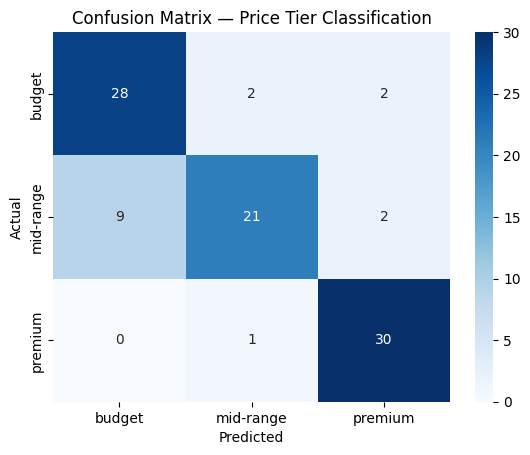

In [57]:
y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels=['budget', 'mid-range', 'premium'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['budget', 'mid-range', 'premium'],
            yticklabels=['budget', 'mid-range', 'premium'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — Price Tier Classification')
plt.show()

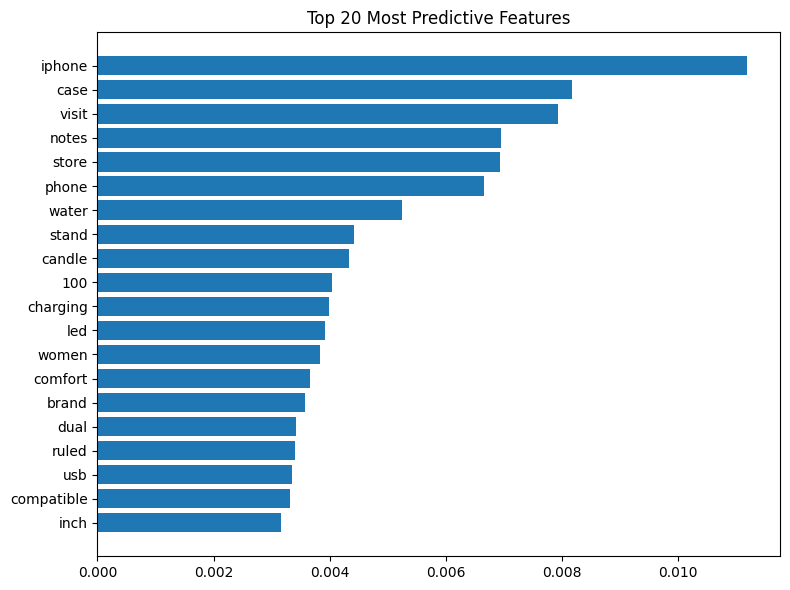

In [58]:
tfidf_features = clf.named_steps['preprocessor'].named_transformers_['tfidf'].get_feature_names_out()
all_features = np.concatenate([tfidf_features, numeric_cols])
importances = clf.named_steps['model'].feature_importances_

top_idx = np.argsort(importances)[-20:]
plt.figure(figsize=(8, 6))
plt.barh(range(len(top_idx)), importances[top_idx])
plt.yticks(range(len(top_idx)), [all_features[i] for i in top_idx])
plt.title('Top 20 Most Predictive Features')
plt.tight_layout()
plt.show()

In [59]:
def predict_tier(title, description, brand, review_count=0, rating=0):
    row = pd.DataFrame([{
        'text_features': f"{title} {description} {brand}",
        'review_count': review_count,
        'rating': rating
    }])
    return clf.predict(row)[0]

# Example
predict_tier("Wireless Noise Cancelling Headphones", "Premium sound with 40hr battery", "SonyX", review_count=1200, rating=4.6)

'premium'

## Feature Importance